# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [3]:
df_california = pd.read_csv('california_dataset.csv')

In [4]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

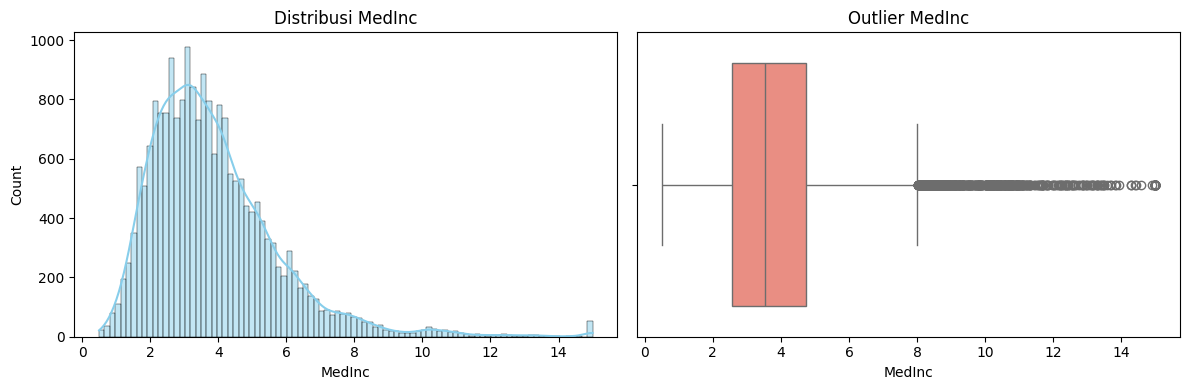

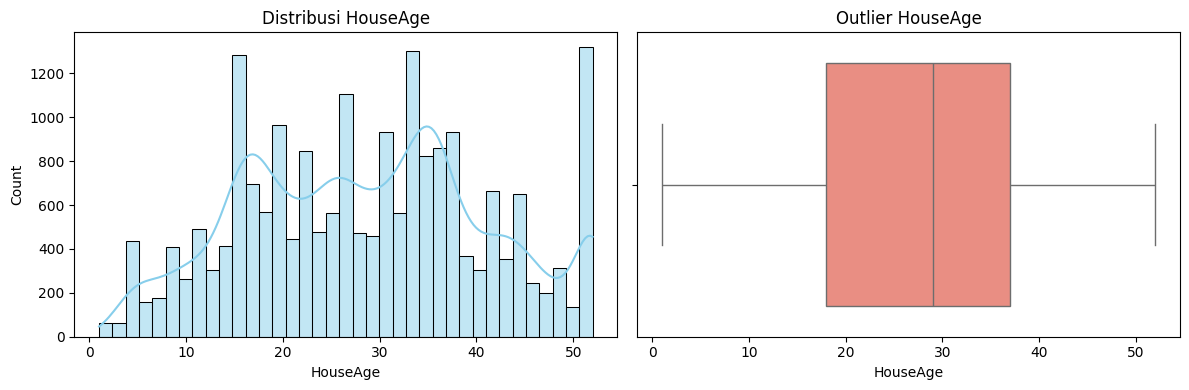

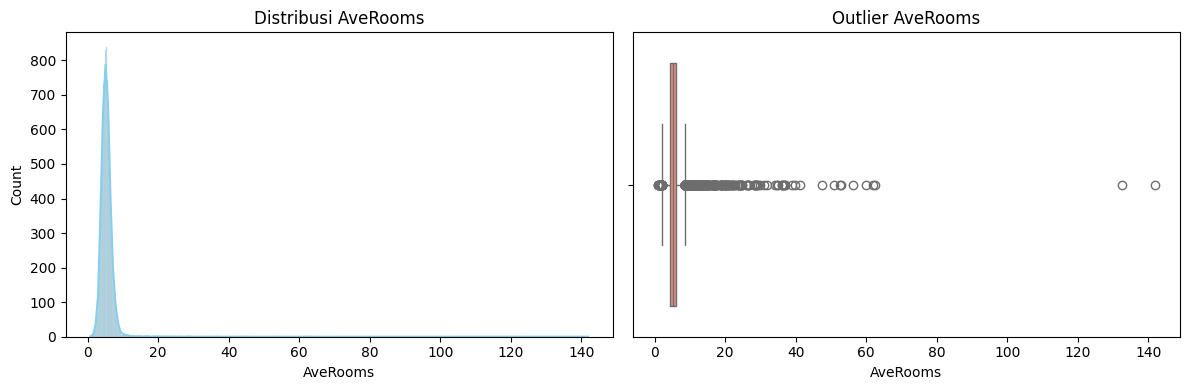

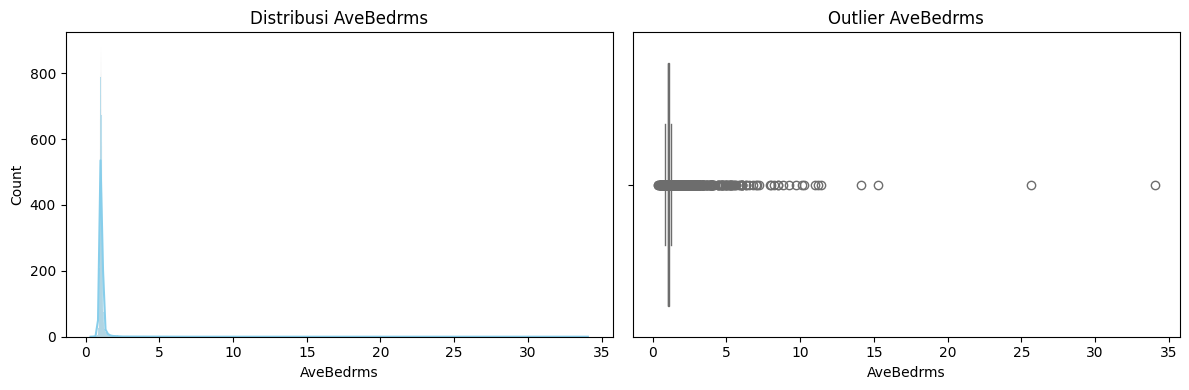

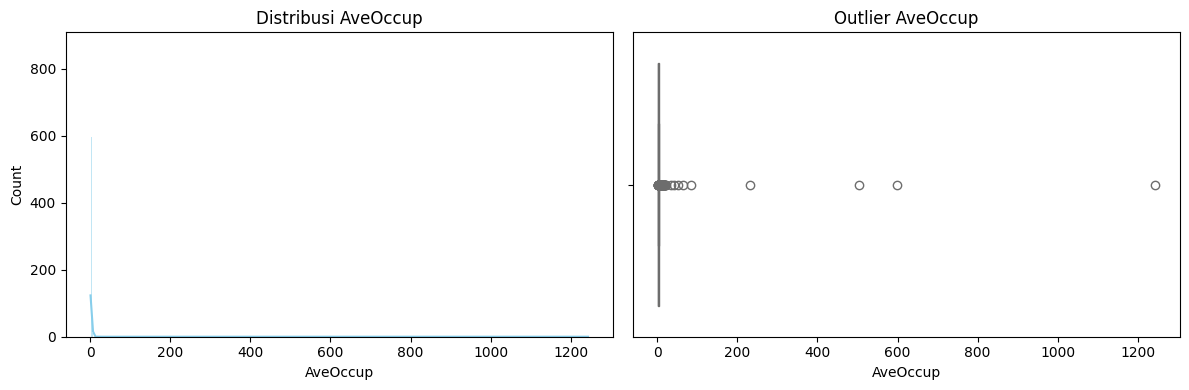

In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('california_dataset.csv')

kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for col in kolom_kolom:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribusi {col}')
    
    sns.boxplot(x=df[col], ax=axes[1], color='salmon')
    axes[1].set_title(f'Outlier {col}')
    
    plt.tight_layout()
    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

Jumlah data awal: 20640
Jumlah data setelah handling: 20129
Data yang terbuang: 511


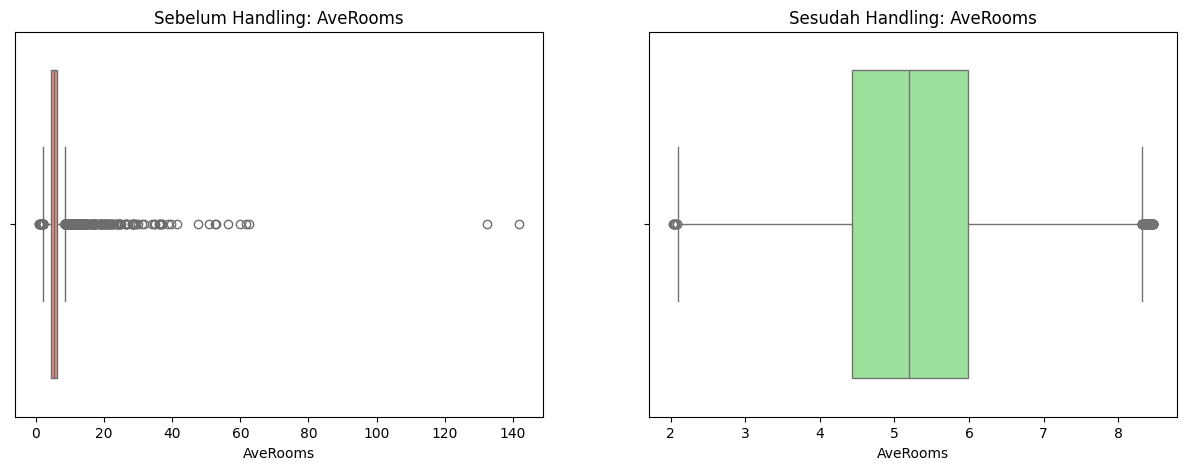

In [ ]:
target_col = 'AveRooms'

Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)]

print(f"Jumlah data awal: {len(df)}")
print(f"Jumlah data setelah handling: {len(df_cleaned)}")
print(f"Data yang terbuang: {len(df) - len(df_cleaned)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df[target_col], ax=axes[0], color='salmon')
axes[0].set_title(f'Sebelum Handling: {target_col}')
sns.boxplot(x=df_cleaned[target_col], ax=axes[1], color='lightgreen')
axes[1].set_title(f'Sesudah Handling: {target_col}')

plt.show()


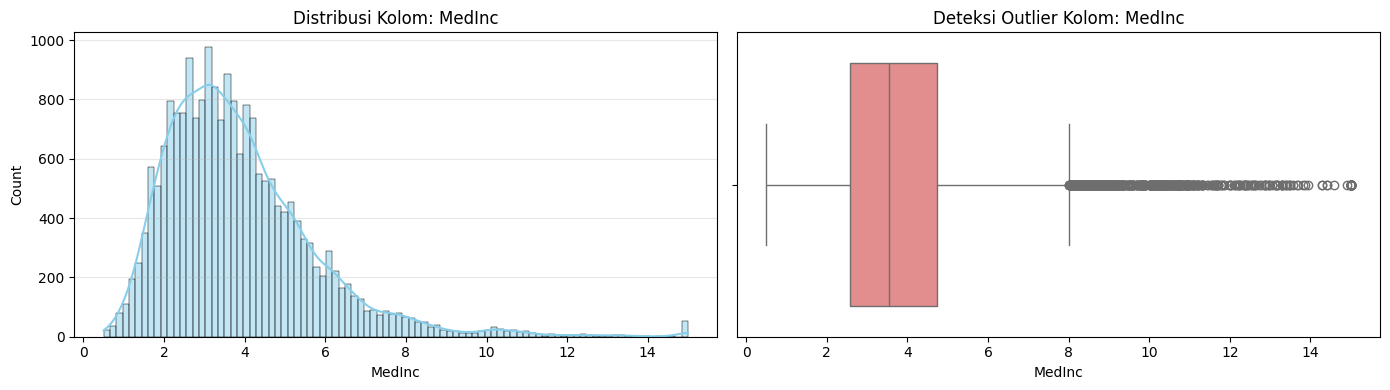

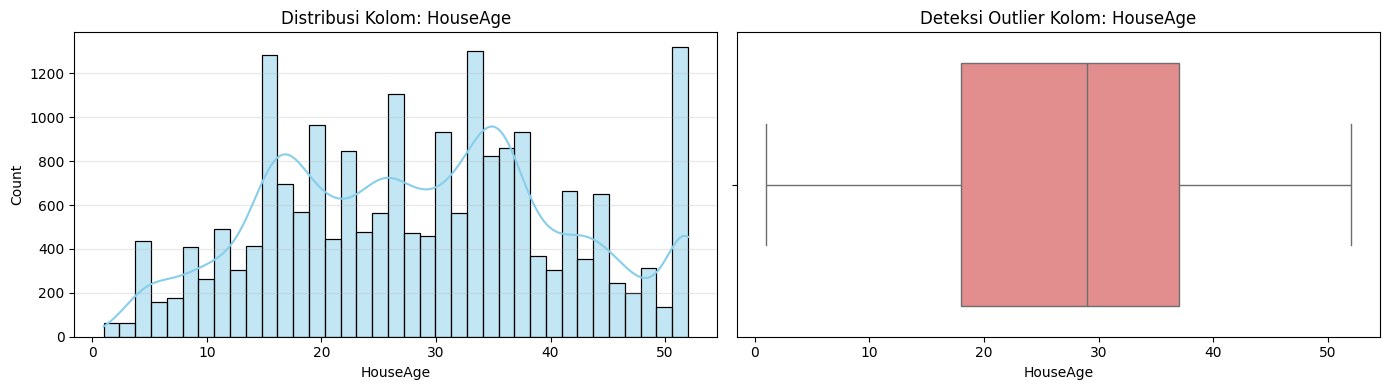

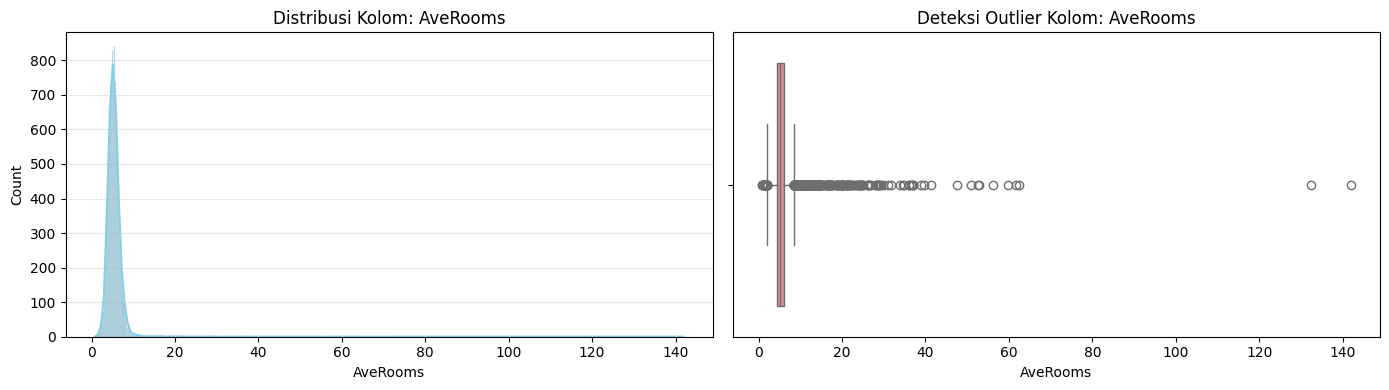

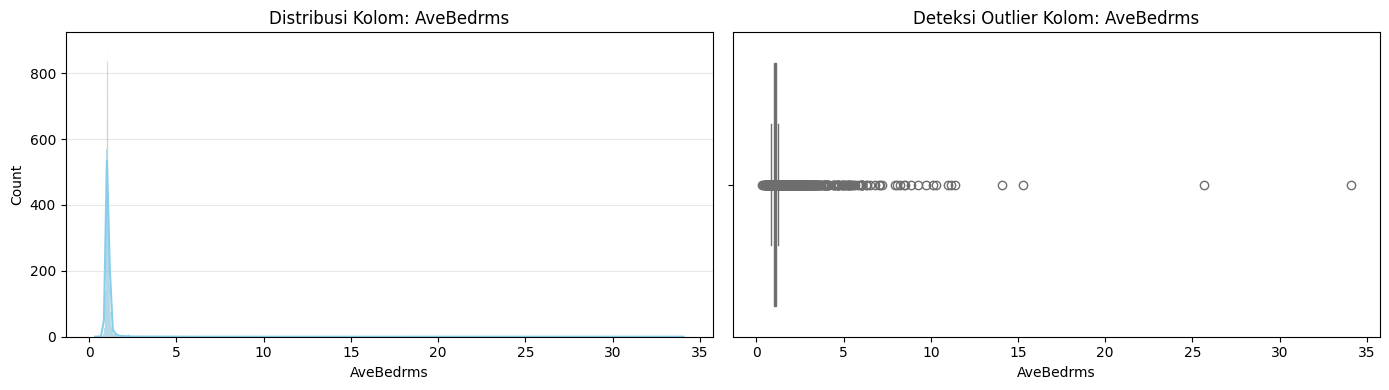

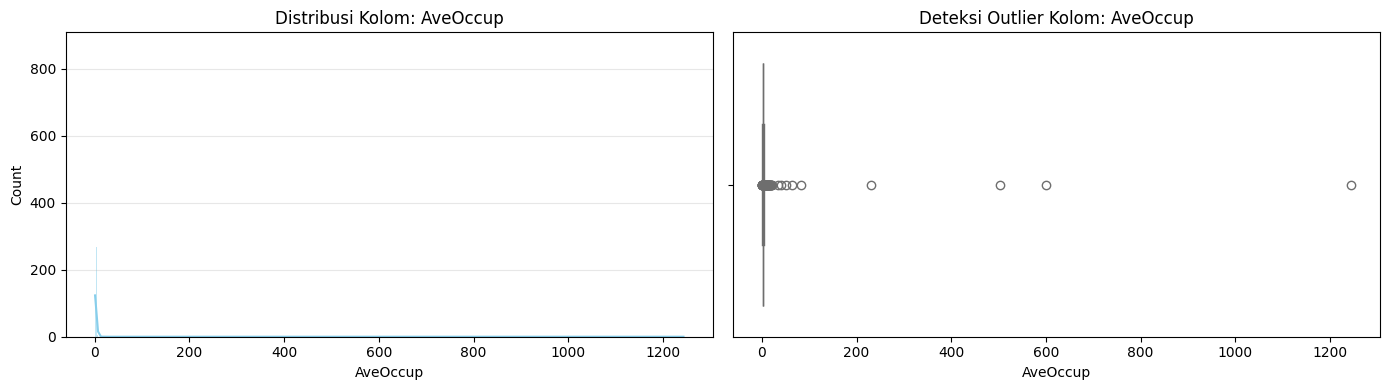

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for col in kolom_kolom:
    plt.figure(figsize=(14, 4))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi Kolom: {col}')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Deteksi Outlier Kolom: {col}')
    
    plt.tight_layout()
    plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [ ]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [ ]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [ ]:
import pandas as pd

df_company = pd.read_csv('company.csv')

# Cek persentase missing value
missing_count = df_company['Headquarters'].isnull().sum()
total_rows = len(df_company)
persentase_missing = (missing_count / total_rows) * 100

print(f"Kolom: Headquarters")
print(f"Jumlah Missing Value: {missing_count}")
print(f"Persentase: {persentase_missing:.2f}%")

# Logika Handling > 20%
if persentase_missing > 20:
    print("Keputusan: Drop kolom karena > 20%")
else:
    print("Keputusan: Tidak di-drop (<= 20%), lakukan handling.")
    # Menggunakan modus
    modus_hq = df_company['Headquarters'].mode()[0]
    df_company['Headquarters'] = df_company['Headquarters'].fillna(modus_hq)
    print(f"Hasil: Missing value diisi dengan modus '{modus_hq}'")


Kolom: Headquarters
Jumlah Missing Value: 0
Persentase: 0.00%
Keputusan: Tidak di-drop (<= 20%), lakukan handling.
Hasil: Missing value diisi dengan modus 'New York, NY'


In [15]:
print(df.columns.tolist())


['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'house_price']


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [ ]:
df_churn = pd.read_csv('Telco-Customer-Churn.csv')

In [ ]:
#Splitting terlebih dahulu


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [21]:
from sklearn.preprocessing import LabelEncoder

kolom_target = ['StreamingMovies', 'StreamingTV', 'TechSupport', 
                'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

for col in kolom_target:
    df_telco[col] = df_telco[col].replace({'No internet service': 'No', 'No phone service': 'No'})

print("--- Hasil setelah validasi ---")
for col in kolom_target:
    print(f"Kolom {col}:\n{df_telco[col].value_counts()}\n")

le = LabelEncoder()

for col in kolom_target:
    df_telco[col] = le.fit_transform(df_telco[col])

print("--- Hasil Setelah Label Encoding (5 baris pertama) ---")
print(df_telco[kolom_target].head())

--- Hasil setelah validasi ---
Kolom StreamingMovies:
StreamingMovies
0    4311
1    2732
Name: count, dtype: int64

Kolom StreamingTV:
StreamingTV
0    4336
1    2707
Name: count, dtype: int64

Kolom TechSupport:
TechSupport
0    4999
1    2044
Name: count, dtype: int64

Kolom DeviceProtection:
DeviceProtection
0    4621
1    2422
Name: count, dtype: int64

Kolom OnlineBackup:
OnlineBackup
0    4614
1    2429
Name: count, dtype: int64

Kolom OnlineSecurity:
OnlineSecurity
0    5024
1    2019
Name: count, dtype: int64

Kolom MultipleLines:
MultipleLines
0    4072
1    2971
Name: count, dtype: int64

--- Hasil Setelah Label Encoding (5 baris pertama) ---
   StreamingMovies  StreamingTV  TechSupport  DeviceProtection  OnlineBackup  \
0                0            0            0                 0             1   
1                0            0            0                 1             0   
2                0            0            0                 0             1   
3                0

In [ ]:
import pandas as pd
df_telco = pd.read_csv('TelcoCustomerChurn.csv') 

df_telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Selesai :)